# COVID-19 Supervised Machine Learning Classification Prototype

This notebook cleans and preprocesses the COVID-19 testing dataset, develops three supervised classification algorithms, performs hyperparameter tuning, compares baseline and tuned performance, analyses feature importance, and saves all final tuned models in one deployment bundle.

**Dataset file:** `corona_tested_individuals_ver_006.english.csv.zip`  
**Evaluation priority:** F1-score, because positive cases are the minority class.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import sklearn

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)
print("Scikit-learn version:", sklearn.__version__)

print("\nEnvironment is ready!")

Python version: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
Pandas version: 3.0.5
NumPy version: 2.5.1
Matplotlib version: 3.11.1
Seaborn version: 0.13.2
Scikit-learn version: 1.9.0

Environment is ready!


In [2]:
from pathlib import Path

dataset_filename = "corona_tested_individuals_ver_006.english.csv.zip"
dataset_url = (
    "https://raw.githubusercontent.com/"
    "nshomron/covidpred/master/data/"
    + dataset_filename
)

local_dataset = Path.cwd() / dataset_filename
dataset_source = (
    local_dataset
    if local_dataset.exists()
    else dataset_url
)

try:
    df = pd.read_csv(
        dataset_source,
        compression="zip",
        low_memory=False
    )
except Exception as error:
    raise RuntimeError(
        "Dataset loading failed. Check the internet connection "
        "or place the ZIP dataset in the same folder as this notebook."
    ) from error

required_columns = {
    "test_date",
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache",
    "corona_result",
    "age_60_and_above",
    "gender",
    "test_indication"
}

missing_columns = required_columns - set(df.columns)

if df.empty:
    raise ValueError("The dataset is empty.")

if missing_columns:
    raise ValueError(
        "Dataset columns are missing: "
        + ", ".join(sorted(missing_columns))
    )

print("Dataset loaded successfully!")
print("Dataset source:", dataset_source)
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset source: https://raw.githubusercontent.com/nshomron/covidpred/master/data/corona_tested_individuals_ver_006.english.csv.zip
Dataset shape: (278848, 10)


In [3]:
display(df.head())

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


In [4]:
print("Column names:")

for column in df.columns:
    print("-", column)

Column names:
- test_date
- cough
- fever
- sore_throat
- shortness_of_breath
- head_ache
- corona_result
- age_60_and_above
- gender
- test_indication


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   test_date            278848 non-null  str    
 1   cough                278596 non-null  float64
 2   fever                278596 non-null  float64
 3   sore_throat          278847 non-null  float64
 4   shortness_of_breath  278847 non-null  float64
 5   head_ache            278847 non-null  float64
 6   corona_result        278848 non-null  str    
 7   age_60_and_above     151528 non-null  str    
 8   gender               259285 non-null  str    
 9   test_indication      278848 non-null  str    
dtypes: float64(5), str(5)
memory usage: 29.2 MB


In [6]:
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
})

display(
    missing_table.sort_values(
        by="Missing Values",
        ascending=False
    )
)

,Missing Values,Missing Percentage (%)
age_60_and_above,127320,45.66
gender,19563,7.02
fever,252,0.09
cough,252,0.09
head_ache,1,0.00
sore_throat,1,0.00
shortness_of_breath,1,0.00
test_date,0,0.00
corona_result,0,0.00
test_indication,0,0.00


In [7]:
print("Corona result distribution:")
print(df["corona_result"].value_counts(dropna=False))

Corona result distribution:
corona_result
negative    260227
positive     14729
other         3892
Name: count, dtype: int64


In [8]:
categorical_columns = [
    "age_60_and_above",
    "gender",
    "test_indication"
]

for column in categorical_columns:
    print(f"\nColumn: {column}")
    print(df[column].value_counts(dropna=False))


Column: age_60_and_above
age_60_and_above
NaN    127320
No     125703
Yes     25825
Name: count, dtype: int64

Column: gender
gender
female    130158
male      129127
NaN        19563
Name: count, dtype: int64

Column: test_indication
test_indication
Other                     242741
Abroad                     25468
Contact with confirmed     10639
Name: count, dtype: int64


In [9]:
clean_df = df.copy()

print("Original dataset shape:", clean_df.shape)

Original dataset shape: (278848, 10)


In [10]:
text_columns = [
    "corona_result",
    "age_60_and_above",
    "gender",
    "test_indication"
]

for column in text_columns:
    clean_df[column] = (
        clean_df[column]
        .astype("string")
        .str.strip()
        .str.lower()
    )

print("Text values standardized successfully!")

Text values standardized successfully!


In [11]:
clean_df = clean_df[
    clean_df["corona_result"].isin([
        "positive",
        "negative"
    ])
].copy()

print("Records after removing 'other':", len(clean_df))

print("\nRemaining target values:")
print(clean_df["corona_result"].value_counts())

Records after removing 'other': 274956

Remaining target values:
corona_result
negative    260227
positive     14729
Name: count, dtype: int64[pyarrow]


In [12]:
clean_df["target"] = clean_df["corona_result"].map({
    "negative": 0,
    "positive": 1
})

print(clean_df[[
    "corona_result",
    "target"
]].head(10))

  corona_result  target
0      negative       0
1      negative       0
2      negative       0
3      negative       0
4      negative       0
5      negative       0
6      negative       0
7      negative       0
8      negative       0
9      negative       0


In [13]:
categorical_columns = [
    "age_60_and_above",
    "gender",
    "test_indication"
]

clean_df[categorical_columns] = (
    clean_df[categorical_columns]
    .fillna("unknown")
)

print("Categorical missing values handled!")

Categorical missing values handled!


In [14]:
symptom_columns = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache"
]

for column in symptom_columns:
    # Make sure the values are numeric
    clean_df[column] = pd.to_numeric(
        clean_df[column],
        errors="coerce"
    )

    # Find the most frequently occurring value
    most_common_value = clean_df[column].mode()[0]

    # Fill missing values
    clean_df[column] = (
        clean_df[column]
        .fillna(most_common_value)
        .astype(int)
    )

    print(
        column,
        "filled with:",
        most_common_value
    )

cough filled with: 0.0
fever filled with: 0.0
sore_throat filled with: 0.0
shortness_of_breath filled with: 0.0
head_ache filled with: 0.0


In [15]:
clean_df = clean_df.drop(
    columns=[
        "test_date",
        "corona_result"
    ]
)

print("Unused columns removed!")

Unused columns removed!


In [16]:
print("Cleaned dataset shape:", clean_df.shape)

print("\nMissing values after preprocessing:")
print(clean_df.isna().sum())

print("\nTarget distribution:")
print(clean_df["target"].value_counts())

display(clean_df.head())

Cleaned dataset shape: (274956, 9)

Missing values after preprocessing:
cough                  0
fever                  0
sore_throat            0
shortness_of_breath    0
head_ache              0
age_60_and_above       0
gender                 0
test_indication        0
target                 0
dtype: int64

Target distribution:
target
0    260227
1     14729
Name: count, dtype: int64


,cough,fever,sore_throat,shortness_of_breath,head_ache,age_60_and_above,gender,test_indication,target
0,0,0,0,0,0,unknown,female,other,0
1,1,0,0,0,0,unknown,female,other,0
2,0,1,0,0,0,unknown,male,other,0
3,1,0,0,0,0,unknown,female,other,0
4,1,0,0,0,0,unknown,male,other,0


In [17]:
# X contains the input features
X = clean_df.drop(columns=["target"])

# y contains the correct answer
y = clean_df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nInput features:")
print(X.columns.tolist())

X shape: (274956, 8)
y shape: (274956,)

Input features:
['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache', 'age_60_and_above', 'gender', 'test_indication']


In [18]:
class_distribution = pd.DataFrame({
    "Count": y.value_counts(),
    "Percentage (%)": (
        y.value_counts(normalize=True) * 100
    ).round(2)
})

class_distribution.index = [
    "Negative (0)",
    "Positive (1)"
]

display(class_distribution)

,Count,Percentage (%)
Negative (0),260227,94.64
Positive (1),14729,5.36


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (219964, 8)
Testing feature shape: (54992, 8)
Training target shape: (219964,)
Testing target shape: (54992,)


In [20]:
print("Training target distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting target distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training target distribution:
target
0    94.64
1     5.36
Name: proportion, dtype: float64

Testing target distribution:
target
0    94.64
1     5.36
Name: proportion, dtype: float64


In [21]:
symptom_features = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache"
]

categorical_features = [
    "age_60_and_above",
    "gender",
    "test_indication"
]

print("Symptom features:", symptom_features)
print("Categorical features:", categorical_features)

Symptom features: ['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache']
Categorical features: ['age_60_and_above', 'gender', 'test_indication']


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "symptoms",
            "passthrough",
            symptom_features
        ),
        (
            "categories",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="drop"
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [23]:
X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

print(
    "Encoded training shape:",
    X_train_encoded.shape
)

print(
    "Encoded testing shape:",
    X_test_encoded.shape
)

Encoded training shape: (219964, 14)
Encoded testing shape: (54992, 14)


In [24]:
encoded_feature_names = (
    preprocessor.get_feature_names_out()
)

print("Total encoded features:", len(encoded_feature_names))

for feature in encoded_feature_names:
    print("-", feature)

Total encoded features: 14
- symptoms__cough
- symptoms__fever
- symptoms__sore_throat
- symptoms__shortness_of_breath
- symptoms__head_ache
- categories__age_60_and_above_no
- categories__age_60_and_above_unknown
- categories__age_60_and_above_yes
- categories__gender_female
- categories__gender_male
- categories__gender_unknown
- categories__test_indication_abroad
- categories__test_indication_contact with confirmed
- categories__test_indication_other


### 5.1 Encoded Data Validation

The following checks ensure that preprocessing produced valid numeric data before model training begins. These validations help prevent missing values, inconsistent sample counts, and incomplete target classes from entering the models.

In [25]:
if X_train_encoded.shape[0] != len(y_train):
    raise ValueError("Training feature and target counts do not match.")

if X_test_encoded.shape[0] != len(y_test):
    raise ValueError("Testing feature and target counts do not match.")

if np.isnan(X_train_encoded).any() or np.isnan(X_test_encoded).any():
    raise ValueError("Encoded data contains missing numeric values.")

if set(y_train.unique()) != {0, 1}:
    raise ValueError("The training target must contain classes 0 and 1.")

print("Encoded data validation passed!")
print("Training samples:", X_train_encoded.shape[0])
print("Testing samples:", X_test_encoded.shape[0])
print("Encoded features:", X_train_encoded.shape[1])

Encoded data validation passed!
Training samples: 219964
Testing samples: 54992
Encoded features: 14


## Part 6: Model Development and Hyperparameter Tuning

Each algorithm is developed in two stages:

1. A **baseline model** provides an initial result.
2. A **tuned model** is selected using cross-validation on the training set.

The untouched test set is used only for the final baseline and tuned evaluations. F1-score is the tuning metric because the dataset is highly imbalanced.

In [26]:
import time
import joblib
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    RandomizedSearchCV,
    StratifiedKFold
)
from sklearn.svm import LinearSVC

stratified_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Model development tools imported successfully!")

Model development tools imported successfully!


In [27]:
def evaluate_classifier(
    model_name,
    model,
    X_evaluation,
    y_evaluation,
    training_time,
    colour_map="Blues"
):
    """Evaluate one fitted classifier using consistent metrics."""
    predictions = model.predict(X_evaluation)

    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_evaluation, predictions),
        "Precision": precision_score(
            y_evaluation,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_evaluation,
            predictions,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_evaluation,
            predictions,
            zero_division=0
        ),
        "Training Time": training_time
    }

    print(model_name)
    print("-" * len(model_name))
    print(f"Accuracy : {result['Accuracy']:.4f}")
    print(f"Precision: {result['Precision']:.4f}")
    print(f"Recall   : {result['Recall']:.4f}")
    print(f"F1-score : {result['F1-score']:.4f}")
    print(f"Fit time : {training_time:.2f} seconds")
    print()
    print(
        classification_report(
            y_evaluation,
            predictions,
            target_names=["Negative", "Positive"],
            digits=4,
            zero_division=0
        )
    )

    ConfusionMatrixDisplay.from_predictions(
        y_evaluation,
        predictions,
        display_labels=["Negative", "Positive"],
        cmap=colour_map,
        values_format="d"
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return result, predictions


def display_search_summary(search_object, top_n=5):
    """Display the highest-ranked cross-validation combinations."""
    results = pd.DataFrame(search_object.cv_results_)
    summary = (
        results[[
            "params",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]]
        .sort_values("rank_test_score")
        .head(top_n)
        .reset_index(drop=True)
    )
    display(summary)
    return summary

### 6.1 Logistic Regression

Logistic Regression is first trained with a reasonable baseline iteration limit. GridSearchCV then tunes regularisation strength (`C`), solver, and `max_iter`.

Baseline Logistic Regression
----------------------------
Accuracy : 0.9276
Precision: 0.4039
Recall   : 0.7393
F1-score : 0.5224
Fit time : 0.21 seconds

              precision    recall  f1-score   support

    Negative     0.9845    0.9382    0.9608     52046
    Positive     0.4039    0.7393    0.5224      2946

    accuracy                         0.9276     54992
   macro avg     0.6942    0.8388    0.7416     54992
weighted avg     0.9534    0.9276    0.9373     54992



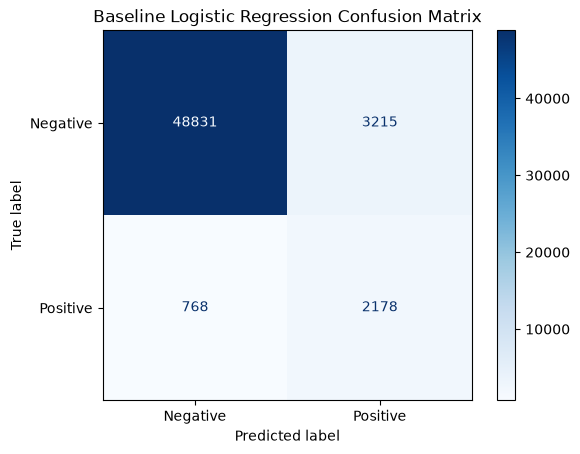

In [28]:
baseline_logistic_model = LogisticRegression(
    max_iter=100,
    class_weight="balanced",
    random_state=42
)

start_time = time.time()
baseline_logistic_model.fit(X_train_encoded, y_train)
baseline_logistic_training_time = time.time() - start_time

baseline_logistic_result, baseline_logistic_predictions = (
    evaluate_classifier(
        "Baseline Logistic Regression",
        baseline_logistic_model,
        X_test_encoded,
        y_test,
        baseline_logistic_training_time,
        "Blues"
    )
)

In [29]:
logistic_parameter_grid = {
    "solver": ["liblinear", "lbfgs"],
    "C": [0.01, 0.1, 1.0, 10.0],
    "max_iter": [100, 200]
}

logistic_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        class_weight="balanced",
        random_state=42
    ),
    param_grid=logistic_parameter_grid,
    scoring="f1",
    cv=stratified_cv,
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

logistic_combination_count = len(
    list(ParameterGrid(logistic_parameter_grid))
)

print("Parameter combinations:", logistic_combination_count)
print("Total cross-validation fits:", logistic_combination_count * 3)

Parameter combinations: 16
Total cross-validation fits: 48


In [30]:
logistic_tuning_start = time.time()
logistic_grid_search.fit(X_train_encoded, y_train)
logistic_tuning_time = time.time() - logistic_tuning_start

tuned_logistic_model = logistic_grid_search.best_estimator_

print("Logistic Regression tuning completed!")
print("Best parameters:", logistic_grid_search.best_params_)
print(f"Best cross-validation F1: {logistic_grid_search.best_score_:.4f}")
print(f"Total tuning time: {logistic_tuning_time:.2f} seconds")
print(
    "Iterations used by selected model:",
    int(np.max(tuned_logistic_model.n_iter_))
)

logistic_cv_summary = display_search_summary(
    logistic_grid_search
)

Logistic Regression tuning completed!
Best parameters: {'C': 1.0, 'max_iter': 100, 'solver': 'lbfgs'}
Best cross-validation F1: 0.5045
Total tuning time: 10.91 seconds
Iterations used by selected model: 16


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'C': 10.0, 'max_iter': 100, 'solver': 'lbfgs'}",0.504846,0.504545,0.021855,1
1,"{'C': 10.0, 'max_iter': 200, 'solver': 'lbfgs'}",0.504846,0.504545,0.021855,1
2,"{'C': 1.0, 'max_iter': 200, 'solver': 'lbfgs'}",0.504846,0.504545,0.021855,1
3,"{'C': 1.0, 'max_iter': 100, 'solver': 'lbfgs'}",0.504846,0.504545,0.021855,1
4,"{'C': 10.0, 'max_iter': 200, 'solver': 'liblin...",0.504133,0.503776,0.022941,5


Logistic Regression
-------------------
Accuracy : 0.9276
Precision: 0.4039
Recall   : 0.7393
F1-score : 0.5224
Fit time : 0.22 seconds

              precision    recall  f1-score   support

    Negative     0.9845    0.9382    0.9608     52046
    Positive     0.4039    0.7393    0.5224      2946

    accuracy                         0.9276     54992
   macro avg     0.6942    0.8388    0.7416     54992
weighted avg     0.9534    0.9276    0.9373     54992



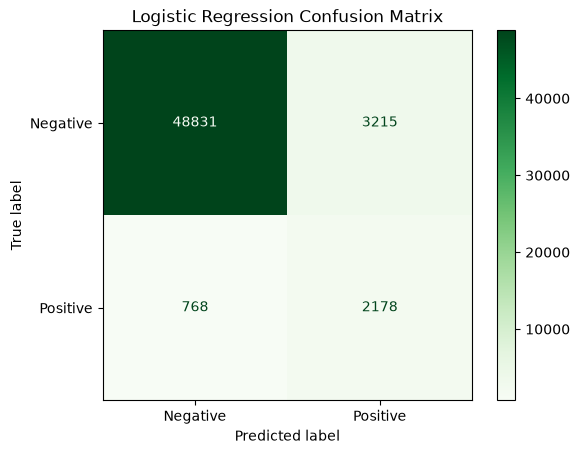

,Model,Accuracy,Precision,Recall,F1-score,Training Time
0,Baseline Logistic Regression,0.9276,0.4039,0.7393,0.5224,0.21
1,Logistic Regression,0.9276,0.4039,0.7393,0.5224,0.22


F1-score change: +0.0000


In [31]:
tuned_logistic_result, tuned_logistic_predictions = (
    evaluate_classifier(
        "Logistic Regression",
        tuned_logistic_model,
        X_test_encoded,
        y_test,
        logistic_grid_search.refit_time_,
        "Greens"
    )
)

logistic_before_after = pd.DataFrame([
    baseline_logistic_result,
    tuned_logistic_result
])

display(
    logistic_before_after.round({
        "Accuracy": 4,
        "Precision": 4,
        "Recall": 4,
        "F1-score": 4,
        "Training Time": 2
    })
)

print(
    "F1-score change:",
    f"{tuned_logistic_result['F1-score'] - baseline_logistic_result['F1-score']:+.4f}"
)

### 6.2 Random Forest

Random Forest is evaluated with a simple baseline and then tuned using RandomizedSearchCV. Random search is suitable here because Random Forest has many possible parameter combinations and testing every combination would require unnecessary computation.

Baseline Random Forest
----------------------
Accuracy : 0.9239
Precision: 0.3939
Recall   : 0.7797
F1-score : 0.5234
Fit time : 3.70 seconds

              precision    recall  f1-score   support

    Negative     0.9868    0.9321    0.9587     52046
    Positive     0.3939    0.7797    0.5234      2946

    accuracy                         0.9239     54992
   macro avg     0.6904    0.8559    0.7410     54992
weighted avg     0.9550    0.9239    0.9354     54992



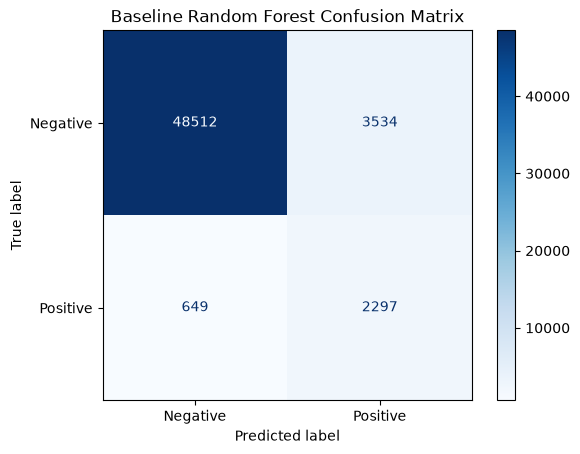

In [32]:
baseline_random_forest_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
baseline_random_forest_model.fit(X_train_encoded, y_train)
baseline_random_forest_training_time = time.time() - start_time

baseline_random_forest_result, baseline_random_forest_predictions = (
    evaluate_classifier(
        "Baseline Random Forest",
        baseline_random_forest_model,
        X_test_encoded,
        y_test,
        baseline_random_forest_training_time,
        "Blues"
    )
)

In [33]:
random_forest_parameter_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 12, 16, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"]
}

random_forest_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=1
    ),
    param_distributions=(
        random_forest_parameter_distributions
    ),
    n_iter=12,
    scoring="f1",
    cv=stratified_cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

print("RandomizedSearchCV will test 12 sampled combinations.")
print("Total cross-validation fits:", 12 * 3)

RandomizedSearchCV will test 12 sampled combinations.
Total cross-validation fits: 36


In [34]:
random_forest_tuning_start = time.time()
random_forest_random_search.fit(X_train_encoded, y_train)
random_forest_tuning_time = (
    time.time() - random_forest_tuning_start
)

tuned_random_forest_model = (
    random_forest_random_search.best_estimator_
)
tuned_random_forest_model.set_params(n_jobs=-1)

print("Random Forest tuning completed!")
print(
    "Best parameters:",
    random_forest_random_search.best_params_
)
print(
    "Best cross-validation F1:",
    f"{random_forest_random_search.best_score_:.4f}"
)
print(
    "Total tuning time:",
    f"{random_forest_tuning_time:.2f} seconds"
)

random_forest_cv_summary = display_search_summary(
    random_forest_random_search
)

Random Forest tuning completed!
Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini'}
Best cross-validation F1: 0.5279
Total tuning time: 172.61 seconds


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.530094,0.527853,0.010158,1
1,"{'n_estimators': 300, 'min_samples_split': 2, ...",0.530112,0.527806,0.010043,2
2,"{'n_estimators': 200, 'min_samples_split': 10,...",0.528913,0.526405,0.010240,3
3,"{'n_estimators': 100, 'min_samples_split': 10,...",0.528880,0.526404,0.010223,4
4,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.529247,0.526328,0.010263,5


Random Forest
-------------
Accuracy : 0.9283
Precision: 0.4103
Recall   : 0.7756
F1-score : 0.5367
Fit time : 9.68 seconds

              precision    recall  f1-score   support

    Negative     0.9866    0.9369    0.9611     52046
    Positive     0.4103    0.7756    0.5367      2946

    accuracy                         0.9283     54992
   macro avg     0.6985    0.8563    0.7489     54992
weighted avg     0.9558    0.9283    0.9384     54992



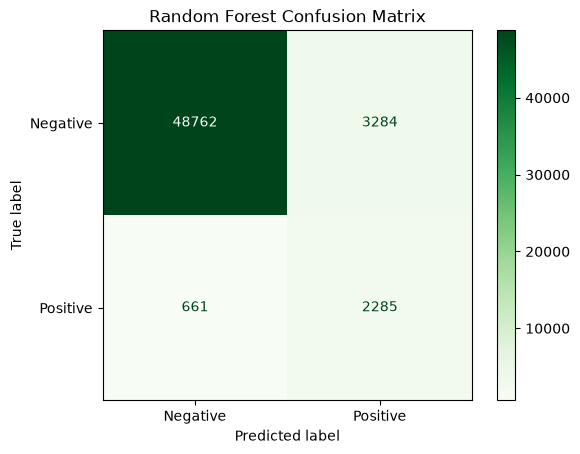

,Model,Accuracy,Precision,Recall,F1-score,Training Time
0,Baseline Random Forest,0.9239,0.3939,0.7797,0.5234,3.70
1,Random Forest,0.9283,0.4103,0.7756,0.5367,9.68


F1-score change: +0.0133


In [35]:
tuned_random_forest_result, tuned_random_forest_predictions = (
    evaluate_classifier(
        "Random Forest",
        tuned_random_forest_model,
        X_test_encoded,
        y_test,
        random_forest_random_search.refit_time_,
        "Greens"
    )
)

random_forest_before_after = pd.DataFrame([
    baseline_random_forest_result,
    tuned_random_forest_result
])

display(
    random_forest_before_after.round({
        "Accuracy": 4,
        "Precision": 4,
        "Recall": 4,
        "F1-score": 4,
        "Training Time": 2
    })
)

print(
    "F1-score change:",
    f"{tuned_random_forest_result['F1-score'] - baseline_random_forest_result['F1-score']:+.4f}"
)

#### Random Forest Feature Importance

Feature importance shows which encoded inputs contribute most strongly to the tuned Random Forest predictions. The analysis supports model interpretation without removing features prematurely. Because this prototype has only a small number of meaningful features, all features are retained for the final model.

,Feature,Importance
12,categories__test_indication_contact with confi...,0.267191
13,categories__test_indication_other,0.247667
1,symptoms__fever,0.155658
0,symptoms__cough,0.102409
4,symptoms__head_ache,0.053963
11,categories__test_indication_abroad,0.043137
2,symptoms__sore_throat,0.032677
6,categories__age_60_and_above_unknown,0.032330
3,symptoms__shortness_of_breath,0.026868
5,categories__age_60_and_above_no,0.010499


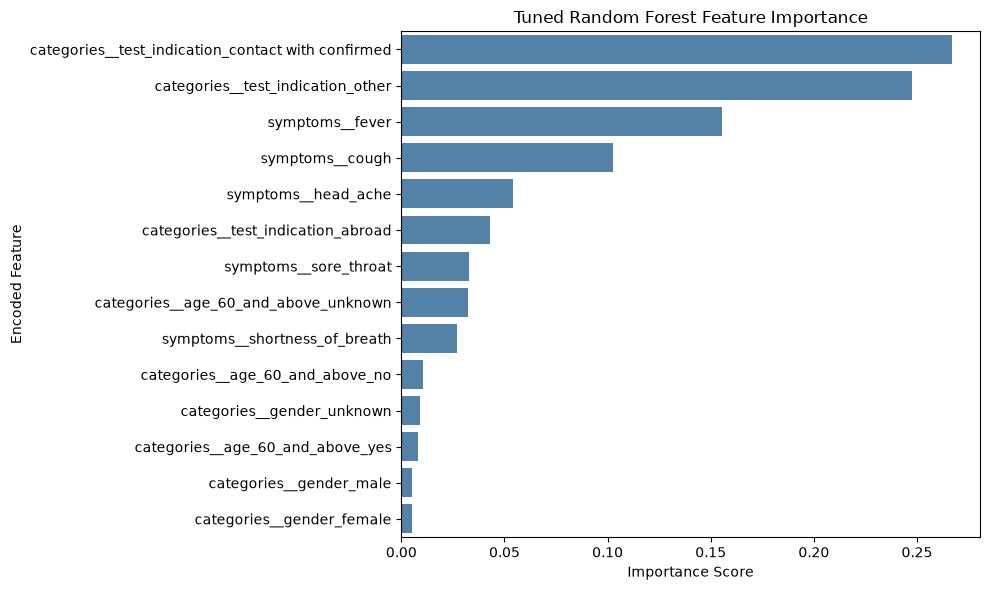

In [36]:
feature_importance_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": tuned_random_forest_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature",
    color="steelblue"
)
plt.title("Tuned Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Encoded Feature")
plt.tight_layout()
plt.show()

### 6.3 Linear Support Vector Machine

Linear SVM is suitable for the encoded feature space and trains quickly. GridSearchCV tunes its regularisation strength (`C`), class weighting, tolerance, and iteration limit.

Baseline Linear SVM
-------------------
Accuracy : 0.9223
Precision: 0.3839
Recall   : 0.7447
F1-score : 0.5066
Fit time : 0.33 seconds

              precision    recall  f1-score   support

    Negative     0.9847    0.9323    0.9578     52046
    Positive     0.3839    0.7447    0.5066      2946

    accuracy                         0.9223     54992
   macro avg     0.6843    0.8385    0.7322     54992
weighted avg     0.9526    0.9223    0.9337     54992



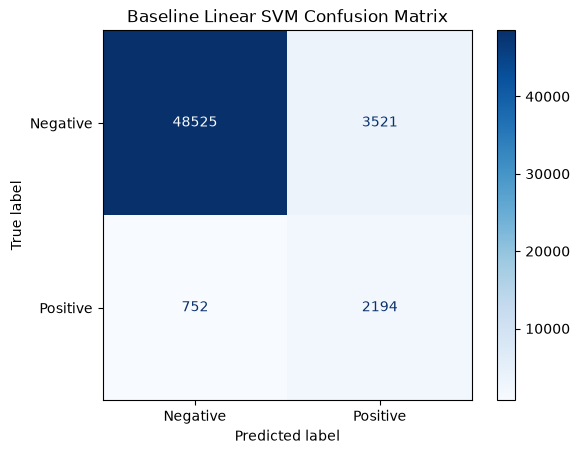

In [37]:
baseline_linear_svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

start_time = time.time()
baseline_linear_svm_model.fit(X_train_encoded, y_train)
baseline_linear_svm_training_time = time.time() - start_time

baseline_linear_svm_result, baseline_linear_svm_predictions = (
    evaluate_classifier(
        "Baseline Linear SVM",
        baseline_linear_svm_model,
        X_test_encoded,
        y_test,
        baseline_linear_svm_training_time,
        "Blues"
    )
)

In [38]:
linear_svm_parameter_grid = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "class_weight": [None, "balanced"],
    "tol": [0.001, 0.0001],
    "max_iter": [1000, 3000]
}

linear_svm_grid_search = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=linear_svm_parameter_grid,
    scoring="f1",
    cv=stratified_cv,
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

svm_combination_count = len(
    list(ParameterGrid(linear_svm_parameter_grid))
)

print("Parameter combinations:", svm_combination_count)
print("Total cross-validation fits:", svm_combination_count * 3)

Parameter combinations: 32
Total cross-validation fits: 96


In [39]:
linear_svm_tuning_start = time.time()
linear_svm_grid_search.fit(X_train_encoded, y_train)
linear_svm_tuning_time = time.time() - linear_svm_tuning_start

tuned_linear_svm_model = (
    linear_svm_grid_search.best_estimator_
)

print("Linear SVM tuning completed!")
print("Best parameters:", linear_svm_grid_search.best_params_)
print(
    "Best cross-validation F1:",
    f"{linear_svm_grid_search.best_score_:.4f}"
)
print(
    "Total tuning time:",
    f"{linear_svm_tuning_time:.2f} seconds"
)
print(
    "Iterations used by selected model:",
    int(tuned_linear_svm_model.n_iter_)
)

linear_svm_cv_summary = display_search_summary(
    linear_svm_grid_search
)

Linear SVM tuning completed!
Best parameters: {'C': 10.0, 'class_weight': None, 'max_iter': 1000, 'tol': 0.001}
Best cross-validation F1: 0.6490
Total tuning time: 11.53 seconds
Iterations used by selected model: 7


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'C': 10.0, 'class_weight': None, 'max_iter': ...",0.649009,0.649008,0.003244,1
1,"{'C': 10.0, 'class_weight': None, 'max_iter': ...",0.649009,0.649008,0.003244,1
2,"{'C': 10.0, 'class_weight': None, 'max_iter': ...",0.648392,0.648119,0.002962,3
3,"{'C': 10.0, 'class_weight': None, 'max_iter': ...",0.648392,0.648119,0.002962,3
4,"{'C': 1.0, 'class_weight': None, 'max_iter': 3...",0.647832,0.647741,0.002520,5


Linear SVM
----------
Accuracy : 0.9659
Precision: 0.7295
Recall   : 0.5777
F1-score : 0.6448
Fit time : 0.29 seconds

              precision    recall  f1-score   support

    Negative     0.9764    0.9879    0.9821     52046
    Positive     0.7295    0.5777    0.6448      2946

    accuracy                         0.9659     54992
   macro avg     0.8530    0.7828    0.8135     54992
weighted avg     0.9632    0.9659    0.9640     54992



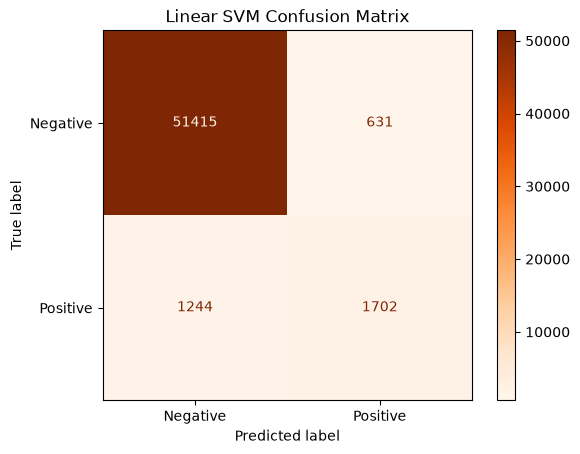

,Model,Accuracy,Precision,Recall,F1-score,Training Time
0,Baseline Linear SVM,0.9223,0.3839,0.7447,0.5066,0.33
1,Linear SVM,0.9659,0.7295,0.5777,0.6448,0.29


F1-score change: +0.1382


In [40]:
tuned_linear_svm_result, tuned_linear_svm_predictions = (
    evaluate_classifier(
        "Linear SVM",
        tuned_linear_svm_model,
        X_test_encoded,
        y_test,
        linear_svm_grid_search.refit_time_,
        "Oranges"
    )
)

linear_svm_before_after = pd.DataFrame([
    baseline_linear_svm_result,
    tuned_linear_svm_result
])

display(
    linear_svm_before_after.round({
        "Accuracy": 4,
        "Precision": 4,
        "Recall": 4,
        "F1-score": 4,
        "Training Time": 2
    })
)

print(
    "F1-score change:",
    f"{tuned_linear_svm_result['F1-score'] - baseline_linear_svm_result['F1-score']:+.4f}"
)

## Part 7: Baseline and Tuned Model Comparison

The following tables compare each baseline with its tuned version. The final deployment decision uses the tuned-model table. F1-score is treated as the main selection metric because it balances precision and recall for the minority positive class.

In [41]:
baseline_comparison_df = pd.DataFrame([
    baseline_logistic_result,
    baseline_random_forest_result,
    baseline_linear_svm_result
])

tuned_comparison_df = pd.DataFrame([
    tuned_logistic_result,
    tuned_random_forest_result,
    tuned_linear_svm_result
])

print("Baseline model comparison")
display(
    baseline_comparison_df.round({
        "Accuracy": 4,
        "Precision": 4,
        "Recall": 4,
        "F1-score": 4,
        "Training Time": 2
    })
)

print("Tuned model comparison")
display(
    tuned_comparison_df.round({
        "Accuracy": 4,
        "Precision": 4,
        "Recall": 4,
        "F1-score": 4,
        "Training Time": 2
    })
)

Baseline model comparison


,Model,Accuracy,Precision,Recall,F1-score,Training Time
0,Baseline Logistic Regression,0.9276,0.4039,0.7393,0.5224,0.21
1,Baseline Random Forest,0.9239,0.3939,0.7797,0.5234,3.70
2,Baseline Linear SVM,0.9223,0.3839,0.7447,0.5066,0.33


Tuned model comparison


,Model,Accuracy,Precision,Recall,F1-score,Training Time
0,Logistic Regression,0.9276,0.4039,0.7393,0.5224,0.22
1,Random Forest,0.9283,0.4103,0.7756,0.5367,9.68
2,Linear SVM,0.9659,0.7295,0.5777,0.6448,0.29


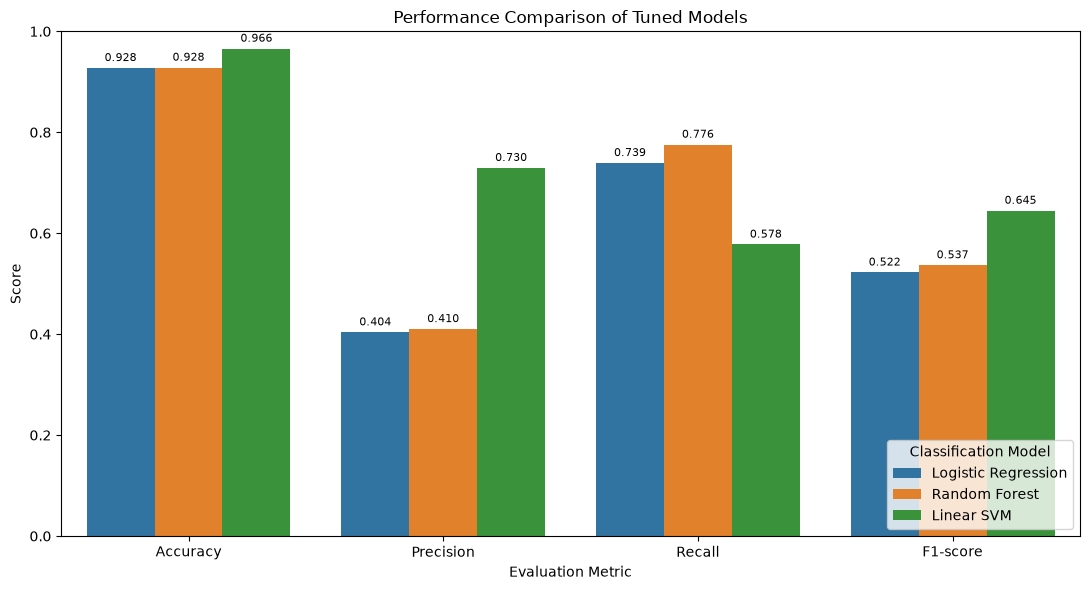

In [42]:
metrics_for_chart = tuned_comparison_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))
comparison_chart = sns.barplot(
    data=metrics_for_chart,
    x="Metric",
    y="Score",
    hue="Model"
)
plt.title("Performance Comparison of Tuned Models")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

for container in comparison_chart.containers:
    comparison_chart.bar_label(
        container,
        fmt="%.3f",
        fontsize=8,
        padding=3
    )

plt.legend(title="Classification Model", loc="lower right")
plt.tight_layout()
plt.show()

In [43]:
best_model_index = tuned_comparison_df["F1-score"].idxmax()
best_model_name = tuned_comparison_df.loc[
    best_model_index,
    "Model"
]
best_model_f1 = tuned_comparison_df.loc[
    best_model_index,
    "F1-score"
]

print("Best tuned model based on F1-score:", best_model_name)
print(f"Best test F1-score: {best_model_f1:.4f}")

for metric in ["Accuracy", "Precision", "Recall", "F1-score"]:
    metric_index = tuned_comparison_df[metric].idxmax()
    print(
        f"Best {metric}:",
        tuned_comparison_df.loc[metric_index, "Model"],
        f"({tuned_comparison_df.loc[metric_index, metric]:.4f})"
    )

Best tuned model based on F1-score: Linear SVM
Best test F1-score: 0.6448
Best Accuracy: Linear SVM (0.9659)
Best Precision: Linear SVM (0.7295)
Best Recall: Random Forest (0.7756)
Best F1-score: Linear SVM (0.6448)


In [44]:
tuned_comparison_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

print(
    "Tuned comparison results saved as "
    "model_comparison_results.csv"
)

Tuned comparison results saved as model_comparison_results.csv


## Part 8: Save All Tuned Models for Deployment

Only one deployment file is created: `all_models_bundle.pkl`. It contains the fitted preprocessor, all three tuned models, their final test metrics, the selected best model, feature names, and tuning information. No separate algorithm bundle is required.

In [45]:
final_models = {
    "Logistic Regression": tuned_logistic_model,
    "Random Forest": tuned_random_forest_model,
    "Linear SVM": tuned_linear_svm_model
}

final_metrics = {}

for result in [
    tuned_logistic_result,
    tuned_random_forest_result,
    tuned_linear_svm_result
]:
    final_metrics[result["Model"]] = {
        "Accuracy": result["Accuracy"],
        "Precision": result["Precision"],
        "Recall": result["Recall"],
        "F1-score": result["F1-score"],
        "Training Time": result["Training Time"]
    }

tuning_summary = {
    "Logistic Regression": {
        "method": "GridSearchCV",
        "best_params": logistic_grid_search.best_params_,
        "best_cv_f1": logistic_grid_search.best_score_
    },
    "Random Forest": {
        "method": "RandomizedSearchCV",
        "best_params": random_forest_random_search.best_params_,
        "best_cv_f1": random_forest_random_search.best_score_
    },
    "Linear SVM": {
        "method": "GridSearchCV",
        "best_params": linear_svm_grid_search.best_params_,
        "best_cv_f1": linear_svm_grid_search.best_score_
    }
}

all_models_bundle = {
    "preprocessor": preprocessor,
    "models": final_models,
    "metrics": final_metrics,
    "best_model": best_model_name,
    "feature_names": encoded_feature_names.tolist(),
    "tuning_summary": tuning_summary
}

In [46]:
bundle_path = Path.cwd() / "all_models_bundle.pkl"

joblib.dump(all_models_bundle, bundle_path)

print("All tuned models saved successfully!")
print("Saved file:", bundle_path.name)
print("Best model:", best_model_name)
print("Models included:", list(final_models.keys()))

All tuned models saved successfully!
Saved file: all_models_bundle.pkl
Best model: Linear SVM
Models included: ['Logistic Regression', 'Random Forest', 'Linear SVM']


In [47]:
verification_bundle = joblib.load(
    "all_models_bundle.pkl"
)

required_bundle_keys = {
    "preprocessor",
    "models",
    "metrics"
}

missing_bundle_keys = (
    required_bundle_keys
    - set(verification_bundle)
)

if missing_bundle_keys:
    raise KeyError(
        "Saved bundle is missing: "
        + ", ".join(sorted(missing_bundle_keys))
    )

expected_model_names = {
    "Logistic Regression",
    "Random Forest",
    "Linear SVM"
}

if set(verification_bundle["models"]) != expected_model_names:
    raise ValueError("The saved bundle does not contain all three models.")

sample_encoded_input = X_test_encoded[:1]

for model_name, model in verification_bundle["models"].items():
    sample_prediction = model.predict(sample_encoded_input)
    print(
        f"{model_name} verification prediction:",
        int(sample_prediction[0])
    )

print("Bundle validation passed and is compatible with app.py!")

Logistic Regression verification prediction: 1
Random Forest verification prediction: 1
Linear SVM verification prediction: 1
Bundle validation passed and is compatible with app.py!


## Final Interpretation Guide

- **Baseline results** show the performance before tuning.
- **Cross-validation F1** is used to select parameters without using the test set during tuning.
- **Tuned test results** estimate performance on unseen data.
- **Feature importance** explains which inputs contribute most to the Random Forest model.
- **F1-score** is the main comparison metric because accuracy can appear high when most records are negative.
- The deployment uses one `all_models_bundle.pkl` containing all three tuned algorithms and the shared preprocessor.